# DATA 266 Lab 1 — Task 1 Live Demo & Viva Notebook
## Team 15 — Anshika Goel and Viraat Chaudhary

This notebook is designed for the **live evaluator demo** of Task 1.

It demonstrates, without retraining:

1. the exact repository artifacts and checkpoints,
2. every checkpoint found in each member's checkpoint directory,
3. checkpoint integrity and finite tensors,
4. dataset / processed validation examples,
5. live loading of the selected best checkpoint,
6. live next-character inference and text generation,
7. live recomputation of checkpoint-dependent validation metrics,
8. saved loss curves and training history,
9. the complete reported metric tables,
10. the complete hyperparameter tables,
11. the exact reported failure cases from committed evidence,
12. the final architecture / hyperparameter / metric comparison,
13. the **shared common-holdout evaluator** used to compare the two frozen checkpoints fairly.

> **Important scientific boundary:** a checkpoint can reproduce inference metrics such as validation cross-entropy,
> perplexity, bits-per-character, and top-1 accuracy. Historical training measurements such as total training time,
> training throughput, peak training memory, and gradient statistics are not recreated by loading a checkpoint;
> those values are shown from the committed training artifacts that recorded the original run.

### Demo order

- **Section A:** environment and artifact preflight
- **Section B:** Anshika Goel model
- **Section C:** Viraat Chaudhary model
- **Section D:** side-by-side comparison
- **Section E:** live common-holdout evaluator
- **Section F:** evaluator-facing final checklist

In [1]:
from __future__ import annotations

import contextlib
import hashlib
import importlib.util
import inspect
import io
import json
import math
import os
import random
import subprocess
import sys
import time
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import yaml

from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 220)

SEED = 20260925
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Kernel executable:", sys.executable)

Python: 3.11.9
PyTorch: 2.13.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Kernel executable: C:\Users\aradh\Desktop\DATA 266 Generative AI and LLM\Lab1\.venv\Scripts\python.exe


In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (
            (candidate / "task1_llm").is_dir()
            and (candidate / "README.md").is_file()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not locate the Lab1 repository root. "
        "Place this notebook inside <Lab1>/demo and start Jupyter from the Lab1 repository."
    )

ROOT = find_repo_root()
TASK1 = ROOT / "task1_llm"
ANSHIKA = TASK1 / "Anshika_Goel"
VIRAAT = TASK1 / "Viraat_Chaudhary"

print("Repository root:", ROOT)
print("Notebook working directory:", Path.cwd().resolve())
print("Task 1 root:", TASK1)

Repository root: C:\Users\aradh\Desktop\DATA 266 Generative AI and LLM\Lab1
Notebook working directory: C:\Users\aradh\Desktop\DATA 266 Generative AI and LLM\Lab1\demo
Task 1 root: C:\Users\aradh\Desktop\DATA 266 Generative AI and LLM\Lab1\task1_llm


# A. Environment and artifact preflight

The evaluator should first see that the notebook is using the expected repository and that the **frozen model evidence exists before any evaluation begins**.

The preflight intentionally requires the committed model configuration, source, checkpoint, metric evidence, loss history, generated samples, and failure analysis for both members.

In [3]:
REQUIRED_RELATIVE = {
    "Anshika": [
        "configs/gpt_char.yaml",
        "code/model.py",
        "code/data.py",
        "code/evaluate_generate.py",
        "checkpoints/best_model.pt",
        "checkpoints/last_checkpoint.pt",
        "outputs/metrics/vocabulary.json",
        "outputs/metrics/split_manifest.json",
        "outputs/metrics/training_history.json",
        "outputs/metrics/training_summary.json",
        "outputs/metrics/evaluation_metrics.json",
        "outputs/plots/loss_curves.png",
        "outputs/samples/generated_samples.json",
        "failure_analysis.md",
        "metrics_report.csv",
    ],
    "Viraat": [
        "configs/gpt_char.yaml",
        "code/model.py",
        "code/data.py",
        "code/evaluate_generate.py",
        "checkpoints/best_model.pt",
        "checkpoints/last_checkpoint.pt",
        "outputs/metrics/vocabulary.json",
        "outputs/metrics/split_manifest.json",
        "outputs/metrics/training_history.json",
        "outputs/metrics/training_summary.json",
        "outputs/metrics/evaluation_metrics.json",
        "outputs/plots/loss_curves.png",
        "outputs/samples/generated_samples.json",
        "failure_analysis.md",
        "metrics_report.csv",
    ],
}

member_roots = {"Anshika": ANSHIKA, "Viraat": VIRAAT}
rows = []

for member, rels in REQUIRED_RELATIVE.items():
    member_root = member_roots[member]
    for rel in rels:
        p = member_root / rel
        rows.append({
            "Member": member,
            "Artifact": rel,
            "Exists": p.exists(),
            "Size (MiB)": round(p.stat().st_size / (1024**2), 3) if p.exists() and p.is_file() else None,
        })

preflight = pd.DataFrame(rows)
display(preflight)

missing = preflight.loc[~preflight["Exists"]]
if not missing.empty:
    raise FileNotFoundError(
        "Required Task 1 demo artifacts are missing:\n"
        + missing[["Member", "Artifact"]].to_string(index=False)
    )

print("TASK 1 ARTIFACT PREFLIGHT: PASSED")

,Member,Artifact,Exists,Size (MiB)
0,Anshika,configs/gpt_char.yaml,True,0.002
1,Anshika,code/model.py,True,0.014
2,Anshika,code/data.py,True,0.013
3,Anshika,code/evaluate_generate.py,True,0.022
4,Anshika,checkpoints/best_model.pt,True,13.607
5,Anshika,checkpoints/last_checkpoint.pt,True,40.894
6,Anshika,outputs/metrics/vocabulary.json,True,0.003
7,Anshika,outputs/metrics/split_manifest.json,True,0.002
8,Anshika,outputs/metrics/training_history.json,True,0.005
9,Anshika,outputs/metrics/training_summary.json,True,0.001


TASK 1 ARTIFACT PREFLIGHT: PASSED


In [4]:
def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        while True:
            block = f.read(chunk_size)
            if not block:
                break
            h.update(block)
    return h.hexdigest()

def load_json(path: Path) -> Any:
    return json.loads(path.read_text(encoding="utf-8"))

def load_yaml(path: Path) -> dict[str, Any]:
    return yaml.safe_load(path.read_text(encoding="utf-8"))

def flatten_dict(d: dict[str, Any], prefix: str = "") -> dict[str, Any]:
    out = {}
    for k, v in d.items():
        key = f"{prefix}.{k}" if prefix else str(k)
        if isinstance(v, dict):
            out.update(flatten_dict(v, key))
        else:
            out[key] = v
    return out

def state_dict_from_checkpoint(checkpoint: Any) -> dict[str, torch.Tensor]:
    if isinstance(checkpoint, dict):
        if isinstance(checkpoint.get("model_state_dict"), dict):
            return checkpoint["model_state_dict"]
        if isinstance(checkpoint.get("state_dict"), dict):
            return checkpoint["state_dict"]
        if checkpoint and all(torch.is_tensor(v) for v in checkpoint.values()):
            return checkpoint
    raise RuntimeError("Could not identify a model state_dict in this checkpoint.")

def checkpoint_inventory(member_root: Path) -> pd.DataFrame:
    records = []
    for path in sorted((member_root / "checkpoints").glob("*.pt")):
        checkpoint = torch.load(path, map_location="cpu", weights_only=False)
        state = state_dict_from_checkpoint(checkpoint)
        finite = all(torch.isfinite(t).all().item() for t in state.values())
        parameter_elements = sum(int(t.numel()) for t in state.values())
        records.append({
            "Checkpoint": path.name,
            "SHA256": sha256_file(path),
            "Size (MiB)": round(path.stat().st_size / (1024**2), 3),
            "State tensors": len(state),
            "State tensor elements": parameter_elements,
            "All tensors finite": finite,
            "Epoch": checkpoint.get("epoch") if isinstance(checkpoint, dict) else None,
            "Global step": checkpoint.get("global_step") if isinstance(checkpoint, dict) else None,
            "Best validation loss": checkpoint.get("best_validation_loss") if isinstance(checkpoint, dict) else None,
        })
    return pd.DataFrame(records)

def read_metrics_csv(member_root: Path) -> pd.DataFrame:
    df = pd.read_csv(member_root / "metrics_report.csv")
    return df

def config_table(member_root: Path) -> pd.DataFrame:
    cfg = load_yaml(member_root / "configs/gpt_char.yaml")
    flat = flatten_dict(cfg)
    return pd.DataFrame(
        [{"Hyperparameter / setting": k, "Value": v} for k, v in flat.items()]
    )

def import_module_from_path(module_path: Path, module_name: str):
    spec = importlib.util.spec_from_file_location(module_name, module_path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Could not import {module_path}")
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module

print("Helper functions loaded.")

Helper functions loaded.


## A1. Inventory **all Task 1 checkpoints**

This is the first checkpoint demonstration. It does not merely check that `best_model.pt` exists.

It opens **every `.pt` checkpoint currently present in each member's `checkpoints/` folder**, identifies the model state dictionary, counts tensors, checks that every saved parameter tensor is finite, and records each checkpoint SHA-256.

For live evaluation below, the selected `best_model.pt` checkpoint is used because that is the checkpoint whose metrics are reported.

In [5]:
for member, member_root in member_roots.items():
    display(Markdown(f"### {member} — checkpoint inventory"))
    inventory = checkpoint_inventory(member_root)
    display(inventory)
    assert not inventory.empty
    assert inventory["All tensors finite"].all()
    assert "best_model.pt" in set(inventory["Checkpoint"])
    print(f"{member}: all discovered checkpoint state tensors are finite.")

### Anshika — checkpoint inventory

,Checkpoint,SHA256,Size (MiB),State tensors,State tensor elements,All tensors finite,Epoch,Global step,Best validation loss
0,best_model.pt,64ad99efc0bf2e49959d3ef54bf5373a4c3a974f0fa333ae4a37e62fac9d2ba3,13.607,86,3582101,True,10,NaN,NaN
1,last_checkpoint.pt,4c1a3dd0cb9a4547b557e2a975bc86e2dd4844c6b6af0b79b3a24aaaa24aa4ba,40.894,86,3582101,True,10,31240.0,0.69373


Anshika: all discovered checkpoint state tensors are finite.


### Viraat — checkpoint inventory

,Checkpoint,SHA256,Size (MiB),State tensors,State tensor elements,All tensors finite,Epoch,Global step,Best validation loss
0,best_model.pt,52e2bddd0dadea877d0230f95e5e267cdd87c2f9c4401ff5817a5bc92d0093f1,12.510,52,3273824,True,10,None,NaN
1,last_checkpoint.pt,77cc51c734024e2a460d765d9caf011c8b6ac9bcff2f01d11dde3e4a7c3ac4e9,38.624,52,3273824,True,10,None,0.863752


Viraat: all discovered checkpoint state tensors are finite.


# B. Anshika Goel — selected Task 1 model

**Architecture summary from the frozen experiment configuration**

- Character-level causal decoder-only GPT
- 5 custom **pre-layer-normalized** Transformer blocks
- model width `d_model = 240`
- 6 attention heads (`40` dimensions/head)
- feed-forward width `d_ff = 960`
- GELU feed-forward activation
- learned token embeddings + learned positional embeddings
- dropout `0.10`
- tied token-embedding / output-projection weights
- context window `256` characters
- 3,557,861 trainable parameters in the reported run

The following cells read the actual committed config/metrics rather than relying on this markdown summary.

In [6]:
display(Markdown("## B1. Full Anshika hyperparameter table"))
anshika_config = load_yaml(ANSHIKA / "configs/gpt_char.yaml")
anshika_hparams = config_table(ANSHIKA)
display(anshika_hparams)

## B1. Full Anshika hyperparameter table

,Hyperparameter / setting,Value
0,experiment.name,anshika_char_gpt_v1
1,experiment.member_name,Anshika Goel
2,experiment.team_number,15
3,experiment.task,Task 1 - GPT-Style LLM From Scratch
4,data.dataset_id,roneneldan/TinyStories
...,...,...
59,evaluation.report_parameter_count,True
60,evaluation.report_training_tokens_per_second,True
61,evaluation.report_generation_tokens_per_second,True
62,evaluation.report_peak_memory,True


In [7]:
display(Markdown("## B2. Anshika checkpoint metadata and integrity"))
anshika_best_path = ANSHIKA / "checkpoints/best_model.pt"
anshika_best = torch.load(anshika_best_path, map_location="cpu", weights_only=False)

print("Checkpoint:", anshika_best_path.relative_to(ROOT))
print("SHA256:", sha256_file(anshika_best_path))
print("Checkpoint keys:", sorted(anshika_best.keys()))
print("Stored epoch:", anshika_best.get("epoch"))
print("Stored global step:", anshika_best.get("global_step"))
print("Stored best validation loss:", anshika_best.get("best_validation_loss"))

anshika_state = state_dict_from_checkpoint(anshika_best)
assert all(torch.isfinite(t).all().item() for t in anshika_state.values())
print("Finite checkpoint tensor check: PASSED")

## B2. Anshika checkpoint metadata and integrity

Checkpoint: task1_llm\Anshika_Goel\checkpoints\best_model.pt
SHA256: 64ad99efc0bf2e49959d3ef54bf5373a4c3a974f0fa333ae4a37e62fac9d2ba3
Checkpoint keys: ['epoch', 'experiment_config', 'model_config', 'model_state_dict', 'validation_loss', 'vocabulary_sha256']
Stored epoch: 10
Stored global step: None
Stored best validation loss: None
Finite checkpoint tensor check: PASSED


In [8]:
display(Markdown("## B3. Load Anshika's best model from the checkpoint"))

anshika_model_module = import_module_from_path(
    ANSHIKA / "code/model.py",
    "task1_demo_anshika_model",
)

if not (
    hasattr(anshika_model_module, "GPTConfig")
    and hasattr(anshika_model_module, "CharacterGPT")
):
    raise RuntimeError(
        "Expected Anshika GPTConfig and CharacterGPT classes were not found in code/model.py."
    )

anshika_model = anshika_model_module.CharacterGPT(
    anshika_model_module.GPTConfig(**anshika_best["model_config"])
)
anshika_model.load_state_dict(anshika_state, strict=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
anshika_model = anshika_model.to(DEVICE)
anshika_model.eval()

anshika_parameter_count = sum(p.numel() for p in anshika_model.parameters())

print("Evaluation device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("Reconstructed parameter count:", anshika_parameter_count)
print("Checkpoint load: PASSED")

## B3. Load Anshika's best model from the checkpoint

Evaluation device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Reconstructed parameter count: 3557861
Checkpoint load: PASSED


In [9]:
display(Markdown("## B4. Sample input from Anshika's processed TinyStories validation set"))

anshika_vocab = load_json(ANSHIKA / "outputs/metrics/vocabulary.json")
anshika_split = load_json(ANSHIKA / "outputs/metrics/split_manifest.json")

anshika_validation_path = (
    TASK1 / "data" / "processed" / "Anshika_Goel" / "validation_sequences.pt"
)

if not anshika_validation_path.is_file():
    raise FileNotFoundError(
        "The exact Anshika processed validation tensor is required for the live demo but is missing:\n"
        + str(anshika_validation_path)
    )

validation_tensor = torch.load(
    anshika_validation_path,
    map_location="cpu",
    weights_only=True,
)

print("Validation tensor:", anshika_validation_path.relative_to(ROOT))
print("Shape:", tuple(validation_tensor.shape))
print("Expected shape:", tuple(anshika_split["validation_tensor_shape"]))
print("SHA256:", sha256_file(anshika_validation_path))
print("Expected SHA256:", anshika_split["validation_tensor_sha256"])

assert tuple(validation_tensor.shape) == tuple(anshika_split["validation_tensor_shape"])
assert sha256_file(anshika_validation_path).lower() == str(
    anshika_split["validation_tensor_sha256"]
).lower()

idx_to_char_raw = anshika_vocab["idx_to_char"]
idx_to_char = {int(k): v for k, v in idx_to_char_raw.items()}

def decode_ids(ids, idx_to_char):
    return "".join(idx_to_char.get(int(i), "�") for i in ids)

row = validation_tensor[0]
sample_input_ids = row[:-1]
sample_target_ids = row[1:]

print("\nFirst validation input window (first 256 characters):")
print("-" * 100)
print(decode_ids(sample_input_ids.tolist(), idx_to_char))
print("-" * 100)
print("Next target character:", repr(decode_ids([sample_target_ids[-1].item()], idx_to_char)))

## B4. Sample input from Anshika's processed TinyStories validation set

Validation tensor: task1_llm\data\processed\Anshika_Goel\validation_sequences.pt
Shape: (10000, 257)
Expected shape: (10000, 257)
SHA256: 848b923271643bf82a2a907ccad7b4981359831ceaa56ed505125c781c3055ab
Expected SHA256: 848b923271643bf82a2a907ccad7b4981359831ceaa56ed505125c781c3055ab

First validation input window (first 256 characters):
----------------------------------------------------------------------------------------------------
Once there was a little boy named Mike, who was so excited for summer. He would go out and pick berries with his daddy.

One day, his daddy told him that they were going to go pick apples in the forest. Mike was ecstatic and gathered his supplies. 

So, of
----------------------------------------------------------------------------------------------------
Next target character: 'f'


In [10]:
display(Markdown("## B5. Live Anshika model output for a prompt"))

char_to_idx = {v: int(k) for k, v in idx_to_char.items()}
unknown_index = int(
    anshika_vocab.get(
        "unknown_index",
        anshika_vocab.get("unk_index", 0),
    )
)

def encode_text(text: str, char_to_idx: dict[str, int], unknown_index: int) -> list[int]:
    return [char_to_idx.get(ch, unknown_index) for ch in text]

def extract_logits(output):
    if torch.is_tensor(output):
        return output
    if isinstance(output, dict):
        for key in ("logits", "output", "predictions"):
            if key in output and torch.is_tensor(output[key]):
                return output[key]
    if isinstance(output, (tuple, list)):
        tensor_candidates = [
            x for x in output
            if torch.is_tensor(x) and x.ndim >= 3
        ]
        if tensor_candidates:
            return tensor_candidates[0]
    raise RuntimeError(f"Could not identify logits from model output type {type(output)}")

def forward_logits(model, input_ids):
    attempts = [
        lambda: model(input_ids),
        lambda: model(input_ids=input_ids),
        lambda: model(input_ids, None, False),
        lambda: model(input_ids=input_ids, targets=None, return_attentions=False),
    ]
    last_error = None
    for attempt in attempts:
        try:
            return extract_logits(attempt())
        except Exception as exc:
            last_error = exc
    raise RuntimeError(f"All forward-call patterns failed: {last_error}")

@torch.inference_mode()
def manual_generate(
    model,
    prompt: str,
    char_to_idx: dict[str, int],
    idx_to_char: dict[int, str],
    unknown_index: int,
    context_length: int,
    max_new_characters: int = 220,
    greedy: bool = True,
    temperature: float = 1.0,
):
    token_ids = encode_text(prompt, char_to_idx, unknown_index)
    generated = list(token_ids)

    for _ in range(max_new_characters):
        context = generated[-context_length:]
        x = torch.tensor(context, dtype=torch.long, device=DEVICE).unsqueeze(0)
        logits = forward_logits(model, x)
        next_logits = logits[0, -1].float()

        if greedy:
            next_id = int(next_logits.argmax().item())
        else:
            scaled = next_logits / float(temperature)
            probs = torch.softmax(scaled, dim=-1)
            next_id = int(torch.multinomial(probs, 1).item())

        generated.append(next_id)

    return decode_ids(generated, idx_to_char)

demo_prompt = "Once upon a time"

start = time.perf_counter()
anshika_live_output = manual_generate(
    anshika_model,
    prompt=demo_prompt,
    char_to_idx=char_to_idx,
    idx_to_char=idx_to_char,
    unknown_index=unknown_index,
    context_length=int(anshika_config["data"]["sequence_length"]),
    max_new_characters=220,
    greedy=True,
)
elapsed = time.perf_counter() - start

print("Input prompt:")
print(repr(demo_prompt))
print("\nLive greedy continuation:")
print("-" * 100)
print(anshika_live_output)
print("-" * 100)
print(f"Live generation elapsed: {elapsed:.3f} s")

## B5. Live Anshika model output for a prompt

Input prompt:
'Once upon a time'

Live greedy continuation:
----------------------------------------------------------------------------------------------------
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she went to the park with her mommy and daddy. They saw a big box of colorful colors and shapes. Lily wanted to play with it, but 
----------------------------------------------------------------------------------------------------
Live generation elapsed: 1.381 s


## B6. Live recomputation of Anshika checkpoint metrics

This evaluates the **entire 10,000-window validation tensor** from the frozen processed split.

The notebook recomputes:

- validation cross-entropy,
- perplexity = `exp(cross-entropy)`,
- bits per character = `cross-entropy / ln(2)`,
- top-1 next-character accuracy.

These are checkpoint-dependent inference metrics and therefore can legitimately be reproduced live.

Training throughput, training memory, total training time, and gradient statistics are historical properties of the original training run and are shown later from the committed run evidence.

In [11]:
@torch.inference_mode()
def evaluate_shifted_tensor(model, tensor, batch_size=32):
    loss_sum = 0.0
    correct = 0
    target_count = 0

    for start_idx in range(0, tensor.shape[0], batch_size):
        rows = tensor[start_idx:start_idx + batch_size].to(DEVICE, dtype=torch.long)
        x = rows[:, :-1]
        y = rows[:, 1:]

        logits = forward_logits(model, x).float()
        vocab_size = logits.shape[-1]

        loss_sum += F.cross_entropy(
            logits.reshape(-1, vocab_size),
            y.reshape(-1),
            reduction="sum",
        ).item()

        correct += (logits.argmax(dim=-1) == y).sum().item()
        target_count += y.numel()

    ce = loss_sum / target_count
    return {
        "validation_cross_entropy": ce,
        "perplexity": math.exp(ce),
        "bits_per_character": ce / math.log(2.0),
        "top1_accuracy": correct / target_count,
        "evaluated_target_characters": target_count,
    }

anshika_live_metrics = evaluate_shifted_tensor(
    anshika_model,
    validation_tensor,
    batch_size=32,
)

anshika_eval_json = load_json(
    ANSHIKA / "outputs/metrics/evaluation_metrics.json"
)

def find_numeric(obj, candidates):
    if isinstance(obj, dict):
        for key in candidates:
            if key in obj and isinstance(obj[key], (int, float)):
                return float(obj[key])
        for value in obj.values():
            found = find_numeric(value, candidates)
            if found is not None:
                return found
    return None

anshika_reported_core = {
    "validation_cross_entropy": find_numeric(
        anshika_eval_json,
        ["cross_entropy_loss", "validation_loss", "validation_cross_entropy"],
    ),
    "perplexity": find_numeric(anshika_eval_json, ["perplexity"]),
    "bits_per_character": find_numeric(
        anshika_eval_json,
        ["bits_per_character", "bpc"],
    ),
    "top1_accuracy": find_numeric(
        anshika_eval_json,
        ["top1_accuracy", "top1_next_character_accuracy"],
    ),
}

rows = []
for metric, live_value in anshika_live_metrics.items():
    if metric == "evaluated_target_characters":
        continue
    reported = anshika_reported_core.get(metric)
    rows.append({
        "Metric": metric,
        "Live recomputation": live_value,
        "Reported artifact": reported,
        "Absolute difference": (
            abs(live_value - reported) if reported is not None else None
        ),
    })

anshika_live_vs_reported = pd.DataFrame(rows)
display(anshika_live_vs_reported)

print("Evaluated target characters:", anshika_live_metrics["evaluated_target_characters"])
print(
    "Note: tiny floating-point differences can occur across GPU/CPU and precision paths; "
    "the live values should agree to the displayed precision used in the report."
)

,Metric,Live recomputation,Reported artifact,Absolute difference
0,validation_cross_entropy,0.693730,0.693730,5.865097e-08
1,perplexity,2.001166,2.001166,1.173703e-07
2,bits_per_character,1.000841,1.000841,8.461546e-08
3,top1_accuracy,0.780338,0.780337,1.171875e-06


Evaluated target characters: 2560000
Note: tiny floating-point differences can occur across GPU/CPU and precision paths; the live values should agree to the displayed precision used in the report.


## B7. Anshika loss curves — reconstructed from the committed epoch history

,epoch,training_loss,validation_loss,perplexity,bits_per_character,generalization_gap,validation_top1_accuracy,training_tokens_per_second,validation_tokens_per_second,epoch_training_seconds,global_step
0,1,1.700381,1.017307,2.765736,1.467663,-0.683075,0.682626,86815.217882,249646.535611,294.879177,3125
1,2,0.986310,0.864268,2.373269,1.246876,-0.122041,0.728075,82214.084437,243899.213679,311.382170,6250
2,3,0.881707,0.797890,2.220849,1.151111,-0.083817,0.748713,80210.933097,240459.984923,319.158486,9374
3,4,0.829790,0.765877,2.150880,1.104927,-0.063913,0.758477,79173.967188,240164.983587,323.338604,12498
4,5,0.799201,0.742357,2.100882,1.070995,-0.056844,0.765679,78744.961766,240260.142420,325.100164,15622
5,6,0.776939,0.726950,2.068762,1.048767,-0.049989,0.770245,78721.356994,240223.413779,325.197646,18745
6,7,0.759546,0.713466,2.041054,1.029314,-0.046079,0.774600,78719.900980,239656.614760,325.203661,21869
7,8,0.745757,0.704207,2.022243,1.015957,-0.041550,0.777060,78803.670277,239712.591345,324.857965,24992
8,9,0.735716,0.697901,2.009530,1.006858,-0.037815,0.779083,78982.735685,241114.336277,324.121465,28116
9,10,0.729267,0.693730,2.001166,1.000841,-0.035537,0.780337,78998.658381,239792.627337,324.056136,31240


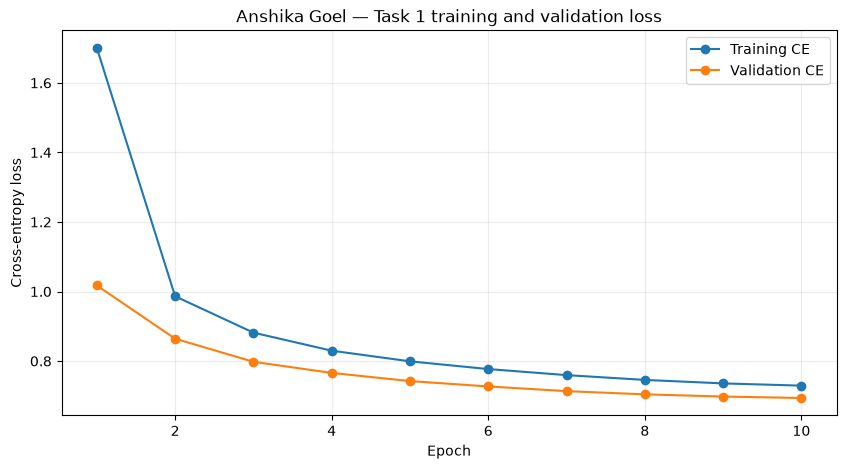

In [12]:
display(Markdown("## B7. Anshika loss curves — reconstructed from the committed epoch history"))

anshika_history = pd.read_csv(
    ANSHIKA / "outputs/metrics/training_history.csv"
)

display(anshika_history)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(anshika_history["epoch"], anshika_history["training_loss"], marker="o", label="Training CE")
ax.plot(anshika_history["epoch"], anshika_history["validation_loss"], marker="o", label="Validation CE")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Anshika Goel — Task 1 training and validation loss")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

In [13]:
display(Markdown("## B8. Anshika — complete reported metrics table"))

anshika_metrics_table = read_metrics_csv(ANSHIKA)
display(anshika_metrics_table)

print(
    "This table is loaded directly from task1_llm/Anshika_Goel/metrics_report.csv. "
    "It includes checkpoint-dependent metrics and historical training/resource metrics."
)

## B8. Anshika — complete reported metrics table

,metric,value,checkpoint_epoch,evidence
0,training_cross_entropy_loss,7.292673e-01,10,outputs/metrics/evaluation_metrics.json
1,validation_cross_entropy_loss,6.937300e-01,10,outputs/metrics/evaluation_metrics.json
2,perplexity,2.001166e+00,10,outputs/metrics/evaluation_metrics.json
3,bits_per_character,1.000841e+00,10,outputs/metrics/evaluation_metrics.json
4,generalization_gap,-3.553731e-02,10,outputs/metrics/evaluation_metrics.json
5,top1_next_character_accuracy,7.803367e-01,10,outputs/metrics/evaluation_metrics.json
6,distinct_1,4.370370e-03,10,outputs/metrics/evaluation_metrics.json
7,distinct_2,3.970905e-02,10,outputs/metrics/evaluation_metrics.json
8,distinct_3,1.581883e-01,10,outputs/metrics/evaluation_metrics.json
9,repeated_4gram_rate,2.223713e-01,10,outputs/metrics/evaluation_metrics.json


This table is loaded directly from task1_llm/Anshika_Goel/metrics_report.csv. It includes checkpoint-dependent metrics and historical training/resource metrics.


## B9. Anshika — reported failure cases

The failure cases below are **not invented for the demo**. They are read from the committed Task 1 failure evidence and linked back to the saved generated outputs.

This distinction matters in a viva:

- a fresh live generation shows that the checkpoint can generate text now;
- the reported failure cases must be demonstrated from the exact saved outputs that were analyzed in the report.

In [14]:
anshika_fail_md = (ANSHIKA / "failure_analysis.md").read_text(encoding="utf-8")
display(Markdown(anshika_fail_md))

anshika_samples = load_json(
    ANSHIKA / "outputs/samples/generated_samples.json"
)
sample_list = anshika_samples.get("samples", anshika_samples)

if isinstance(sample_list, list):
    rows = []
    for sample in sample_list:
        if not isinstance(sample, dict):
            continue
        sample_id = str(
            sample.get("sample_id",
            sample.get("id",
            sample.get("name", "")))
        )
        if sample_id in {"sample_001", "sample_005", "sample_008"}:
            rows.append(sample)
    if rows:
        display(pd.DataFrame(rows))
    else:
        print(
            "The generated-sample schema does not expose sample IDs under the expected key names; "
            "the complete failure_analysis.md above remains the authoritative committed failure evidence."
        )

# Task 1 Sequence Model Failure Analysis - Anshika Goel

## Method

The three cases below were selected from the model's actual generated outputs in `outputs/samples/generated_samples.json`. Each quoted passage is a verbatim excerpt from the corresponding continuation. No failure example was invented or manually corrected.

## Failure Case 1: Sentence-Level Repetition Loop

- Sample ID: `sample_001`
- Prompt: `Once upon a time`
- Decoding method: Greedy
- Temperature: Not applicable
- Repeated 4-gram rate: `0.543260`
- Source: `outputs/samples/generated_samples.json`

Verbatim excerpt:

> She said they were going to the park to play with it. She said they were going to the park to play with it. She said they were going to the park to play with it. She said they were going to the park to play with it.

### Observation

The model initially produces a plausible story about Lily and her parents but becomes trapped in an exact sentence-level loop. The repeated 4-gram rate of approximately 54.33% confirms that more than half of the continuation's 4-gram occurrences duplicate an earlier 4-gram.

### Likely Cause

Greedy decoding always selects the highest-probability next character. Once the model enters a locally probable phrase, it has no randomness or repetition control to help it leave that sequence. The 256-character context window may also reinforce the repeated sentence as it increasingly dominates the recent context.

### Testable Improvement

Add a decoding-time repetition penalty or block previously generated 4-grams. Generate the same prompts with and without this constraint, then compare repeated 4-gram rate and human-rated coherence. The improvement would be supported if repetition decreases without introducing major grammatical degradation.

## Failure Case 2: Pathological Word Repetition

- Sample ID: `sample_005`
- Prompt: `Once upon a time`
- Decoding method: Temperature sampling
- Temperature: `1.0`
- Repeated 4-gram rate: `0.396378`
- Source: `outputs/samples/generated_samples.json`

Verbatim excerpt:

> she found a box of blue blue blue blue blue balls.
>
> She brought it to the blue blue blue blue blue blue blanket! The blue blue blue blue blue blue, near a tree and carrots.

### Observation

The continuation repeatedly emits the word `blue`, producing locally grammatical fragments but no meaningful narrative progression. Its repeated 4-gram rate is approximately 39.64%, the highest among the temperature-1.0 sampled outputs.

### Likely Cause

Because the model predicts one character at a time, a short and common word can become a highly probable self-reinforcing pattern. Standard temperature sampling changes the probability distribution but does not explicitly discourage reuse of recently generated character sequences.

### Testable Improvement

Use unlikelihood training or a decoding penalty targeted at recently repeated character n-grams. Re-run generation at temperature 1.0 with the same seed and compare the frequency of repeated words, repeated 4-gram rate, and story completeness.

## Failure Case 3: Grammar and Semantic Coherence Breakdown

- Sample ID: `sample_008`
- Prompt: `Once upon a time`
- Decoding method: Temperature sampling
- Temperature: `1.3`
- Repeated 4-gram rate: `0.171026`
- Source: `outputs/samples/generated_samples.json`

Verbatim excerpt:

> The nlight was nothing happened, hugged and ran off for bed.
>
> Moral.
>
> Joey was so happy to have opened a bowl very year of.
> Before exhauster his 3 years old and he finished, knowing she was excited.

### Observation

This sample has less mechanical repetition than the first two cases, but it contains malformed words, broken syntax, abrupt transitions, inconsistent pronouns, and unrelated events. Phrases such as `The nlight was nothing happened` and `Before exhauster his 3 years old` are not grammatically or semantically coherent.

### Likely Cause

A temperature of 1.3 flattens the next-character probability distribution, increasing the chance of selecting unlikely characters. Character-level modeling provides no explicit word boundaries or word-level semantic representation, so accumulated low-probability choices can create malformed words and destroy narrative structure.

### Testable Improvement

Use a lower temperature or nucleus sampling that removes the lowest-probability tail before sampling. Compare temperatures 0.7, 1.0, and 1.3 using grammatical-error counts, human coherence ratings, and diversity metrics. A useful decoding setting should preserve some diversity without the severe coherence loss observed here.

## Cross-Case Interpretation

The failures demonstrate a decoding tradeoff:

- Greedy and lower-entropy decoding can become repetitive.
- Moderate sampling can still enter repeated short-word patterns.
- High-temperature sampling increases diversity but damages grammar and coherence.

This interpretation is consistent with the measured results: temperature 1.3 achieved the highest Distinct-3 score (`0.339804`) and the lowest mean repeated 4-gram rate (`0.154706`), but its text was qualitatively less coherent. Therefore, diversity metrics should be interpreted alongside direct inspection of generated language.

,sample_id,prompt_number,prompt,mode,temperature,sample_index,prompt_token_count,continuation_token_count,continuation_token_ids,continuation,complete_text,repeated_4gram_rate
0,sample_001,1,Once upon a time,greedy,NaN,1,16,500,"[11, 2, 75, 63, 60, 73, 60, 2, 78, 56, 74, 2, 56, 2, 67, 64, 75, 75, 67, 60, 2, 62, 64, 73, 67, 2, 69, 56, 68, 60, 5...",", there was a little girl named Lily. She loved to play outside in the sunshine. One day, she went to the park with ...","Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she went t...",0.543260
1,sample_005,1,Once upon a time,sampled,1.0,1,16,500,"[11, 2, 75, 63, 60, 73, 60, 2, 78, 56, 74, 2, 56, 2, 62, 64, 73, 67, 2, 69, 56, 68, 60, 59, 2, 39, 64, 67, 80, 13, 2...",", there was a girl named Lily. She loved to play outside in the sunshine. One day, while she was walking in the wood...","Once upon a time, there was a girl named Lily. She loved to play outside in the sunshine. One day, while she was wal...",0.396378
2,sample_008,1,Once upon a time,sampled,1.3,1,16,500,"[2, 75, 63, 60, 73, 60, 2, 78, 56, 74, 2, 56, 2, 57, 64, 62, 11, 2, 63, 60, 56, 77, 80, 3, 1, 1, 47, 63, 60, 2, 69, ...","there was a big, heavy!\n\nThe nlight was nothing happened, hugged and ran off for bed.\n\nMoral.\n\nJoey was so ha...","Once upon a time there was a big, heavy!\n\nThe nlight was nothing happened, hugged and ran off for bed.\n\nMoral.\n...",0.171026


# C. Viraat Chaudhary — selected Task 1 model

**Architecture summary from the frozen experiment configuration**

- Character-level causal decoder-only Transformer
- 4 custom **post-layer-normalized** Transformer blocks
- model width `d_model = 256`
- 8 attention heads (`32` dimensions/head)
- feed-forward width `d_ff = 1024`
- ReLU feed-forward activation
- learned character + learned positional embeddings
- dropout `0.15`
- untied output projection
- context window `256` characters
- 3,273,824 trainable parameters in the reported run

The model-loading helper below intentionally introspects Viraat's own `code/model.py` at runtime rather than copying a second model implementation into this demo notebook.

In [15]:
display(Markdown("## C1. Full Viraat hyperparameter table"))

viraat_config = load_yaml(VIRAAT / "configs/gpt_char.yaml")
viraat_hparams = config_table(VIRAAT)
display(viraat_hparams)

## C1. Full Viraat hyperparameter table

,Hyperparameter / setting,Value
0,experiment.name,viraat_postnorm_char_gpt_v1
1,experiment.member_name,Viraat Chaudhary
2,experiment.team_number,15
3,data.dataset_id,roneneldan/TinyStories
4,data.dataset_revision,f54c09fd23315a6f9c86f9dc80f725de7d8f9c64
5,data.source_split,train
6,data.text_field,text
7,data.train_sequences,100000
8,data.validation_sequences,10000
9,data.sequence_length,256


In [16]:
display(Markdown("## C2. Viraat checkpoint metadata and integrity"))

viraat_best_path = VIRAAT / "checkpoints/best_model.pt"
viraat_best = torch.load(viraat_best_path, map_location="cpu", weights_only=False)

print("Checkpoint:", viraat_best_path.relative_to(ROOT))
print("SHA256:", sha256_file(viraat_best_path))
print("Checkpoint keys:", sorted(viraat_best.keys()))
print("Stored epoch:", viraat_best.get("epoch"))
print("Stored global step:", viraat_best.get("global_step"))
print("Stored best validation loss:", viraat_best.get("best_validation_loss"))

viraat_state = state_dict_from_checkpoint(viraat_best)
assert all(torch.isfinite(t).all().item() for t in viraat_state.values())
print("Finite checkpoint tensor check: PASSED")

## C2. Viraat checkpoint metadata and integrity

Checkpoint: task1_llm\Viraat_Chaudhary\checkpoints\best_model.pt
SHA256: 52e2bddd0dadea877d0230f95e5e267cdd87c2f9c4401ff5817a5bc92d0093f1
Checkpoint keys: ['config_sha256', 'epoch', 'experiment_config', 'model_config', 'model_state_dict', 'smoke_test', 'split_manifest_sha256', 'validation_loss', 'vocabulary_sha256']
Stored epoch: 10
Stored global step: None
Stored best validation loss: None
Finite checkpoint tensor check: PASSED


In [17]:
display(
    Markdown(
        "## C3. Load Viraat's best model using Viraat's own source module"
    )
)

# ============================================================
# 1. IMPORT VIRAAT'S ACTUAL MODEL IMPLEMENTATION
# ============================================================

viraat_model_module = import_module_from_path(
    VIRAAT / "code" / "model.py",
    "task1_demo_viraat_model",
)

print(
    "Model source:",
    (VIRAAT / "code" / "model.py").relative_to(ROOT),
)


# ============================================================
# 2. VERIFY THE EXPECTED MODEL CLASSES EXIST
# ============================================================

if not hasattr(
    viraat_model_module,
    "DecoderConfig",
):
    raise RuntimeError(
        "DecoderConfig was not found in "
        "Viraat's code/model.py."
    )

if not hasattr(
    viraat_model_module,
    "CharGPT",
):
    raise RuntimeError(
        "CharGPT was not found in "
        "Viraat's code/model.py."
    )

print("DecoderConfig class: FOUND")
print("CharGPT class: FOUND")


# ============================================================
# 3. LOAD VIRAAT'S OWN VOCABULARY
# ============================================================

viraat_vocab = load_json(
    VIRAAT
    / "outputs"
    / "metrics"
    / "vocabulary.json"
)


def infer_vocab_size(
    vocab_obj: dict[str, Any],
) -> int:

    for key in (
        "vocab_size",
        "vocabulary_size",
    ):
        if key in vocab_obj:
            return int(
                vocab_obj[key]
            )

    for key in (
        "idx_to_char",
        "itos",
        "id_to_char",
    ):
        value = vocab_obj.get(
            key
        )

        if isinstance(
            value,
            (dict, list),
        ):
            return len(
                value
            )

    raise RuntimeError(
        "Could not infer Viraat's vocabulary size."
    )


viraat_vocab_size = infer_vocab_size(
    viraat_vocab
)

print(
    "Vocabulary size:",
    viraat_vocab_size,
)


# ============================================================
# 4. READ THE EXACT FROZEN ARCHITECTURE CONFIGURATION
# ============================================================

model_cfg = viraat_config[
    "model"
]

data_cfg = viraat_config[
    "data"
]


viraat_decoder_config = (
    viraat_model_module.DecoderConfig(
        vocab_size=viraat_vocab_size,

        context_length=int(
            data_cfg[
                "sequence_length"
            ]
        ),

        d_model=int(
            model_cfg[
                "d_model"
            ]
        ),

        num_heads=int(
            model_cfg[
                "num_heads"
            ]
        ),

        num_layers=int(
            model_cfg[
                "num_layers"
            ]
        ),

        d_ff=int(
            model_cfg[
                "d_ff"
            ]
        ),

        dropout=float(
            model_cfg[
                "dropout"
            ]
        ),

        epsilon=float(
            model_cfg.get(
                "layer_norm_epsilon",
                1.0e-5,
            )
        ),
    )
)


print()
print(
    "=== VIRAAT DECODER CONFIGURATION ==="
)

print(
    "vocab_size:",
    viraat_decoder_config.vocab_size,
)

print(
    "context_length:",
    viraat_decoder_config.context_length,
)

print(
    "d_model:",
    viraat_decoder_config.d_model,
)

print(
    "num_heads:",
    viraat_decoder_config.num_heads,
)

print(
    "num_layers:",
    viraat_decoder_config.num_layers,
)

print(
    "d_ff:",
    viraat_decoder_config.d_ff,
)

print(
    "dropout:",
    viraat_decoder_config.dropout,
)

print(
    "epsilon:",
    viraat_decoder_config.epsilon,
)


# ============================================================
# 5. RECONSTRUCT THE ACTUAL CHAR-GPT ARCHITECTURE
# ============================================================

viraat_model = (
    viraat_model_module.CharGPT(
        viraat_decoder_config
    )
)

print()
print(
    "Model class:",
    viraat_model.__class__.__name__,
)


# ============================================================
# 6. EXTRACT MODEL WEIGHTS FROM THE BEST CHECKPOINT
# ============================================================

viraat_state = (
    state_dict_from_checkpoint(
        viraat_best
    )
)


print(
    "Checkpoint state tensors:",
    len(
        viraat_state
    ),
)


# ============================================================
# 7. STRICTLY LOAD THE CHECKPOINT
# ============================================================

load_result = (
    viraat_model.load_state_dict(
        viraat_state,
        strict=True,
    )
)


print(
    "Missing keys:",
    load_result.missing_keys,
)

print(
    "Unexpected keys:",
    load_result.unexpected_keys,
)


if load_result.missing_keys:
    raise RuntimeError(
        "Checkpoint is missing model parameters."
    )

if load_result.unexpected_keys:
    raise RuntimeError(
        "Checkpoint contains unexpected parameters."
    )


# ============================================================
# 8. VERIFY ALL CHECKPOINT PARAMETERS ARE FINITE
# ============================================================

all_parameters_finite = all(
    torch.isfinite(
        parameter
    )
    .all()
    .item()

    for parameter
    in viraat_model.parameters()
)


print(
    "All parameters finite:",
    all_parameters_finite,
)


if not all_parameters_finite:
    raise RuntimeError(
        "Non-finite parameter detected "
        "after loading Viraat's checkpoint."
    )


# ============================================================
# 9. MOVE MODEL TO THE DEMO DEVICE
# ============================================================

viraat_model = (
    viraat_model.to(
        DEVICE
    )
)

viraat_model.eval()


# ============================================================
# 10. VERIFY PARAMETER COUNT
# ============================================================

viraat_parameter_count = sum(
    parameter.numel()

    for parameter
    in viraat_model.parameters()

    if parameter.requires_grad
)


expected_parameter_count = (
    3_273_824
)


print()
print(
    "Evaluation device:",
    DEVICE,
)

if DEVICE.type == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(
            0
        ),
    )

print(
    "Reconstructed parameter count:",
    viraat_parameter_count,
)

print(
    "Expected parameter count:",
    expected_parameter_count,
)


if (
    viraat_parameter_count
    != expected_parameter_count
):
    raise RuntimeError(
        "Viraat parameter-count mismatch. "
        f"Expected {expected_parameter_count:,}, "
        f"got {viraat_parameter_count:,}."
    )


# ============================================================
# 11. SHOW IMPORTANT ARCHITECTURAL PROPERTIES
# ============================================================

print()
print(
    "=== ARCHITECTURE VERIFICATION ==="
)

print(
    "Transformer blocks:",
    len(
        viraat_model.blocks
    ),
)

print(
    "Token embedding shape:",
    tuple(
        viraat_model
        .token_embedding
        .weight
        .shape
    ),
)

print(
    "Position embedding shape:",
    tuple(
        viraat_model
        .position_embedding
        .weight
        .shape
    ),
)

print(
    "Output head shape:",
    tuple(
        viraat_model
        .output_head
        .weight
        .shape
    ),
)


# Verify that Viraat's output head is NOT tied
# to the input token embedding.

weights_are_tied = (
    viraat_model
    .token_embedding
    .weight
    .data_ptr()
    ==
    viraat_model
    .output_head
    .weight
    .data_ptr()
)


print(
    "Input/output embedding weights tied:",
    weights_are_tied,
)


if weights_are_tied:
    raise RuntimeError(
        "Viraat's architecture is expected "
        "to use an untied output head."
    )


# ============================================================
# 12. FINAL CHECK
# ============================================================

print()
print(
    "=" * 70
)

print(
    "VIRAAT BEST CHECKPOINT LOADED SUCCESSFULLY"
)

print(
    "=" * 70
)

## C3. Load Viraat's best model using Viraat's own source module

Model source: task1_llm\Viraat_Chaudhary\code\model.py
DecoderConfig class: FOUND
CharGPT class: FOUND
Vocabulary size: 96

=== VIRAAT DECODER CONFIGURATION ===
vocab_size: 96
context_length: 256
d_model: 256
num_heads: 8
num_layers: 4
d_ff: 1024
dropout: 0.15
epsilon: 1e-05

Model class: CharGPT
Checkpoint state tensors: 52
Missing keys: []
Unexpected keys: []
All parameters finite: True

Evaluation device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Reconstructed parameter count: 3273824
Expected parameter count: 3273824

=== ARCHITECTURE VERIFICATION ===
Transformer blocks: 4
Token embedding shape: (96, 256)
Position embedding shape: (256, 256)
Output head shape: (96, 256)
Input/output embedding weights tied: False

VIRAAT BEST CHECKPOINT LOADED SUCCESSFULLY


In [18]:
display(
    Markdown(
        "## C4. Use the same TinyStories validation text with Viraat's vocabulary"
    )
)

# ============================================================
# IMPORTANT:
#
# The local processed validation tensor belongs to Anshika.
# Its INTEGER token IDs cannot be passed directly to Viraat
# because the two models use different character vocabularies.
#
# Correct procedure:
#
# Anshika IDs
#     -> decode with Anshika vocabulary
#     -> same underlying TinyStories characters
#     -> encode with Viraat vocabulary
#     -> Viraat model
#
# This lets both checkpoints see the SAME TEXT.
# ============================================================


# ============================================================
# 1. LOAD ANSHIKA'S VALIDATION TENSOR
# ============================================================

shared_text_source_path = (
    TASK1
    / "data"
    / "processed"
    / "Anshika_Goel"
    / "validation_sequences.pt"
)


if not shared_text_source_path.is_file():

    raise FileNotFoundError(
        "Anshika validation tensor was not found:\n"
        + str(
            shared_text_source_path
        )
    )


anshika_validation_for_shared_demo = (
    torch.load(
        shared_text_source_path,
        map_location="cpu",
        weights_only=True,
    )
    .long()
)


print(
    "Source validation tensor:",
    shared_text_source_path.relative_to(
        ROOT
    ),
)

print(
    "Shape:",
    tuple(
        anshika_validation_for_shared_demo.shape
    ),
)


if tuple(
    anshika_validation_for_shared_demo.shape
) != (
    10_000,
    257,
):

    raise RuntimeError(
        "Expected Anshika validation tensor "
        "shape [10000, 257]."
    )


# ============================================================
# 2. LOAD BOTH CHARACTER VOCABULARIES
# ============================================================

anshika_vocab_for_shared_demo = (
    load_json(
        ANSHIKA
        / "outputs"
        / "metrics"
        / "vocabulary.json"
    )
)


viraat_vocab = (
    load_json(
        VIRAAT
        / "outputs"
        / "metrics"
        / "vocabulary.json"
    )
)


# ============================================================
# 3. NORMALIZE IDX -> CHARACTER MAPPINGS
# ============================================================

def get_idx_to_char(
    vocab_obj,
):

    raw = (
        vocab_obj.get(
            "idx_to_char"
        )
        or vocab_obj.get(
            "id_to_char"
        )
        or vocab_obj.get(
            "itos"
        )
    )


    if isinstance(
        raw,
        dict,
    ):

        return {
            int(index): character

            for index, character
            in raw.items()
        }


    if isinstance(
        raw,
        list,
    ):

        return {
            index: character

            for index, character
            in enumerate(
                raw
            )
        }


    raise RuntimeError(
        "Could not identify "
        "idx-to-character mapping."
    )


anshika_idx_to_char = (
    get_idx_to_char(
        anshika_vocab_for_shared_demo
    )
)


viraat_idx_to_char = (
    get_idx_to_char(
        viraat_vocab
    )
)


viraat_char_to_idx = {

    character: index

    for index, character
    in viraat_idx_to_char.items()

}


print()
print(
    "Anshika vocabulary size:",
    len(
        anshika_idx_to_char
    ),
)

print(
    "Viraat vocabulary size:",
    len(
        viraat_idx_to_char
    ),
)


# ============================================================
# 4. DETERMINE VIRAAT'S UNKNOWN-CHARACTER INDEX
# ============================================================

def find_unknown_index(
    vocab_obj,
    char_to_idx,
):

    # Explicit numeric index fields.
    for key in (
        "unknown_index",
        "unk_index",
        "unk_id",
        "unknown_id",
    ):

        if key in vocab_obj:

            return int(
                vocab_obj[
                    key
                ]
            )


    # Explicit token-name fields.
    for key in (
        "unknown_token",
        "unk_token",
    ):

        token = (
            vocab_obj.get(
                key
            )
        )

        if (
            token is not None
            and token
            in char_to_idx
        ):

            return int(
                char_to_idx[
                    token
                ]
            )


    # Common representations.
    for token in (
        "<UNK>",
        "<unk>",
        "[UNK]",
        "�",
    ):

        if token in char_to_idx:

            return int(
                char_to_idx[
                    token
                ]
            )


    return None


viraat_unknown_index = (
    find_unknown_index(
        viraat_vocab,
        viraat_char_to_idx,
    )
)


print(
    "Viraat unknown-character index:",
    viraat_unknown_index,
)


# ============================================================
# 5. CREATE ANSHIKA-ID -> VIRAAT-ID REMAPPING
#
# This is MUCH faster than decoding and re-encoding every
# character in every one of the 10,000 sequences.
#
# But conceptually it is exactly:
#
# Anshika ID -> character -> Viraat ID
# ============================================================

max_anshika_id = max(
    anshika_idx_to_char
)


id_remap = torch.empty(
    max_anshika_id + 1,
    dtype=torch.long,
)


missing_characters = []


for (
    anshika_id,
    character,
) in sorted(
    anshika_idx_to_char.items()
):

    if (
        character
        in viraat_char_to_idx
    ):

        id_remap[
            anshika_id
        ] = (
            viraat_char_to_idx[
                character
            ]
        )


    else:

        missing_characters.append(
            (
                anshika_id,
                character,
            )
        )


        if (
            viraat_unknown_index
            is None
        ):

            # Temporarily set to zero.
            # We will stop below instead
            # of silently using it.
            id_remap[
                anshika_id
            ] = 0

        else:

            id_remap[
                anshika_id
            ] = (
                viraat_unknown_index
            )


print()
print(
    "Characters in Anshika vocabulary "
    "not present in Viraat vocabulary:",
    len(
        missing_characters
    ),
)


if missing_characters:

    display(
        pd.DataFrame(
            missing_characters,
            columns=[
                "Anshika ID",
                "Character",
            ],
        )
    )


    if (
        viraat_unknown_index
        is None
    ):

        # Check whether any missing character
        # actually appears in the validation set.

        used_ids = set(
            anshika_validation_for_shared_demo
            .unique()
            .tolist()
        )


        missing_used = [

            (
                index,
                character,
            )

            for (
                index,
                character,
            )
            in missing_characters

            if index in used_ids

        ]


        if missing_used:

            raise RuntimeError(
                "The shared validation text contains "
                "characters absent from Viraat's vocabulary, "
                "and no Viraat unknown-character index "
                "could be identified."
            )


# ============================================================
# 6. SAFETY CHECK BEFORE REMAPPING
# ============================================================

source_min = int(
    anshika_validation_for_shared_demo
    .min()
    .item()
)

source_max = int(
    anshika_validation_for_shared_demo
    .max()
    .item()
)


print()
print(
    "Anshika source ID range:",
    (
        source_min,
        source_max,
    ),
)


if (
    source_min < 0
    or source_max
    >= id_remap.numel()
):

    raise RuntimeError(
        "Anshika validation tensor contains "
        "an ID outside its vocabulary mapping."
    )


# ============================================================
# 7. RE-ENCODE THE SAME TEXT FOR VIRAAT
# ============================================================

viraat_demo_validation_tensor = (
    id_remap[
        anshika_validation_for_shared_demo
    ]
)


viraat_demo_min = int(
    viraat_demo_validation_tensor
    .min()
    .item()
)

viraat_demo_max = int(
    viraat_demo_validation_tensor
    .max()
    .item()
)


print()
print(
    "Viraat re-encoded tensor shape:",
    tuple(
        viraat_demo_validation_tensor.shape
    ),
)

print(
    "Viraat re-encoded ID range:",
    (
        viraat_demo_min,
        viraat_demo_max,
    ),
)

print(
    "Valid Viraat ID range:",
    (
        0,
        viraat_vocab_size - 1,
    ),
)


# This check prevents another CUDA device-side assert.

if (
    viraat_demo_min < 0
    or viraat_demo_max
    >= viraat_vocab_size
):

    raise RuntimeError(
        "Re-encoded validation tensor contains "
        "an invalid Viraat token ID."
    )


# ============================================================
# 8. SHOW THE SAME UNDERLYING TEXT
# ============================================================

row_number = 0


anshika_row = (
    anshika_validation_for_shared_demo[
        row_number
    ]
)


viraat_row = (
    viraat_demo_validation_tensor[
        row_number
    ]
)


raw_text = "".join(

    anshika_idx_to_char[
        int(token_id)
    ]

    for token_id
    in anshika_row.tolist()

)


viraat_decoded_text = "".join(

    viraat_idx_to_char[
        int(token_id)
    ]

    for token_id
    in viraat_row.tolist()

)


print()
print(
    "=" * 100
)

print(
    "SAME UNDERLYING TINYSTORIES TEXT"
)

print(
    "=" * 100
)


print()
print(
    "Input characters [0:256]:"
)

print(
    "-" * 100
)

print(
    raw_text[
        :-1
    ]
)

print(
    "-" * 100
)


print(
    "Next character target:",
    repr(
        raw_text[
            -1
        ]
    ),
)


print()
print(
    "Decoded again after "
    "Viraat vocabulary encoding:"
)

print(
    "-" * 100
)

print(
    viraat_decoded_text[
        :-1
    ]
)

print(
    "-" * 100
)


# ============================================================
# 9. VERIFY ROUND TRIP WHEN NO UNKNOWN SUBSTITUTION OCCURRED
# ============================================================

if (
    not missing_characters
):

    assert (
        raw_text
        ==
        viraat_decoded_text
    )

    print(
        "Exact text preserved after "
        "Viraat re-encoding: True"
    )

else:

    print(
        "Exact text preservation may differ only "
        "where Viraat must use its unknown-character token."
    )


print()
print(
    "SHARED-TEXT INPUT PREPARATION: PASSED"
)

## C4. Use the same TinyStories validation text with Viraat's vocabulary

Source validation tensor: task1_llm\data\processed\Anshika_Goel\validation_sequences.pt
Shape: (10000, 257)

Anshika vocabulary size: 101
Viraat vocabulary size: 96
Viraat unknown-character index: 0

Characters in Anshika vocabulary not present in Viraat vocabulary: 10


,Anshika ID,Character
0,5,#
1,10,*
2,54,\
3,85,°
4,86,±
5,87,³
6,88,´
7,91,Ä
8,95,‚
9,98,‹



Anshika source ID range: (1, 100)

Viraat re-encoded tensor shape: (10000, 257)
Viraat re-encoded ID range: (0, 95)
Valid Viraat ID range: (0, 95)

SAME UNDERLYING TINYSTORIES TEXT

Input characters [0:256]:
----------------------------------------------------------------------------------------------------
Once there was a little boy named Mike, who was so excited for summer. He would go out and pick berries with his daddy.

One day, his daddy told him that they were going to go pick apples in the forest. Mike was ecstatic and gathered his supplies. 

So, of
----------------------------------------------------------------------------------------------------
Next character target: 'f'

Decoded again after Viraat vocabulary encoding:
----------------------------------------------------------------------------------------------------
Once there was a little boy named Mike, who was so excited for summer. He would go out and pick berries with his daddy.

One day, his daddy told him that t

In [19]:
display(Markdown("## C5. Live Viraat model output for a prompt"))

viraat_char_to_idx = {v: int(k) for k, v in viraat_idx_to_char.items()}
viraat_unknown_index = int(
    viraat_vocab.get(
        "unknown_index",
        viraat_vocab.get(
            "unk_index",
            viraat_vocab.get("unk_id", 0),
        ),
    )
)

demo_prompt = "Once upon a time"

start = time.perf_counter()
viraat_live_output = manual_generate(
    viraat_model,
    prompt=demo_prompt,
    char_to_idx=viraat_char_to_idx,
    idx_to_char=viraat_idx_to_char,
    unknown_index=viraat_unknown_index,
    context_length=int(viraat_config["data"]["sequence_length"]),
    max_new_characters=220,
    greedy=True,
)
elapsed = time.perf_counter() - start

print("Input prompt:")
print(repr(demo_prompt))
print("\nLive greedy continuation:")
print("-" * 100)
print(viraat_live_output)
print("-" * 100)
print(f"Live generation elapsed: {elapsed:.3f} s")

## C5. Live Viraat model output for a prompt

Input prompt:
'Once upon a time'

Live greedy continuation:
----------------------------------------------------------------------------------------------------
Once upon a time, there was a little girl named Lily. She loved to play with her toys and said, "Thank you, Lily. You are very sad. You are a good friend. You are very sad. You are a good friend. You are very sad. You are a good friend.
----------------------------------------------------------------------------------------------------
Live generation elapsed: 0.708 s


In [20]:
display(
    Markdown(
        "## C6. Live Viraat evaluation on the same TinyStories validation text"
    )
)


# ============================================================
# SCIENTIFIC BOUNDARY
#
# This validation text comes from the local Anshika
# processed validation tensor.
#
# We decoded the underlying characters and re-encoded
# exactly that text using Viraat's own vocabulary.
#
# Therefore this is a valid SAME-TEXT live checkpoint
# demonstration.
#
# It is NOT claimed to reproduce Viraat's original
# member-specific validation split.
#
# Exact reported common-holdout reproduction is performed
# later using task1_llm/evaluate_common.py.
# ============================================================


print(
    "Evaluation set:",
    "same TinyStories validation text, "
    "re-encoded with Viraat vocabulary",
)

print(
    "Sequences:",
    viraat_demo_validation_tensor.shape[
        0
    ],
)

print(
    "Characters per stored row:",
    viraat_demo_validation_tensor.shape[
        1
    ],
)

print(
    "Model vocabulary size:",
    viraat_vocab_size,
)


# ============================================================
# 1. CRITICAL SAFETY CHECKS BEFORE CUDA
# ============================================================

evaluation_min_id = int(
    viraat_demo_validation_tensor
    .min()
    .item()
)

evaluation_max_id = int(
    viraat_demo_validation_tensor
    .max()
    .item()
)


print()
print(
    "Evaluation token-ID range:",
    (
        evaluation_min_id,
        evaluation_max_id,
    ),
)

print(
    "Allowed token-ID range:",
    (
        0,
        viraat_vocab_size - 1,
    ),
)


if (
    evaluation_min_id < 0
    or evaluation_max_id
    >= viraat_vocab_size
):

    raise RuntimeError(
        "STOP: invalid target ID detected "
        "before CUDA evaluation."
    )


print(
    "Token-ID safety check: PASSED"
)


# ============================================================
# 2. LIVE FULL EVALUATION
# ============================================================

print()
print(
    "Running Viraat's frozen checkpoint "
    "on all 10,000 shared text windows..."
)


if (
    DEVICE.type
    == "cuda"
):

    torch.cuda.synchronize()


evaluation_start = (
    time.perf_counter()
)


viraat_same_text_metrics = (
    evaluate_shifted_tensor(
        viraat_model,
        viraat_demo_validation_tensor,
        batch_size=32,
    )
)


if (
    DEVICE.type
    == "cuda"
):

    torch.cuda.synchronize()


evaluation_elapsed = (
    time.perf_counter()
    -
    evaluation_start
)


# ============================================================
# 3. DISPLAY LIVE METRICS
# ============================================================

live_metric_rows = [

    {
        "Metric":
            "Validation cross-entropy",

        "Live value":
            viraat_same_text_metrics[
                "validation_cross_entropy"
            ],
    },

    {
        "Metric":
            "Perplexity",

        "Live value":
            viraat_same_text_metrics[
                "perplexity"
            ],
    },

    {
        "Metric":
            "Bits per character",

        "Live value":
            viraat_same_text_metrics[
                "bits_per_character"
            ],
    },

    {
        "Metric":
            "Top-1 next-character accuracy",

        "Live value":
            viraat_same_text_metrics[
                "top1_accuracy"
            ],
    },

    {
        "Metric":
            "Evaluated target characters",

        "Live value":
            viraat_same_text_metrics[
                "evaluated_target_characters"
            ],
    },

]


viraat_same_text_table = (
    pd.DataFrame(
        live_metric_rows
    )
)


display(
    viraat_same_text_table
)


print()
print(
    "Evaluation runtime:",
    f"{evaluation_elapsed:.3f} seconds",
)


# ============================================================
# 4. SHOW THE FORMULAS USED
# ============================================================

ce_value = (
    viraat_same_text_metrics[
        "validation_cross_entropy"
    ]
)


calculated_perplexity = (
    math.exp(
        ce_value
    )
)


calculated_bpc = (
    ce_value
    /
    math.log(
        2.0
    )
)


print()
print(
    "=== METRIC FORMULA CHECK ==="
)

print(
    "Perplexity = exp(cross-entropy)"
)

print(
    "Computed:",
    calculated_perplexity,
)

print(
    "Reported by evaluator:",
    viraat_same_text_metrics[
        "perplexity"
    ],
)


print()
print(
    "Bits per character = "
    "cross-entropy / ln(2)"
)

print(
    "Computed:",
    calculated_bpc,
)

print(
    "Reported by evaluator:",
    viraat_same_text_metrics[
        "bits_per_character"
    ],
)


assert math.isclose(
    calculated_perplexity,
    viraat_same_text_metrics[
        "perplexity"
    ],
    rel_tol=1e-10,
)


assert math.isclose(
    calculated_bpc,
    viraat_same_text_metrics[
        "bits_per_character"
    ],
    rel_tol=1e-10,
)


print()
print(
    "Metric formula verification: PASSED"
)


# ============================================================
# 5. DISPLAY VIRAAT'S HISTORICAL REPORTED METRICS SEPARATELY
# ============================================================

display(
    Markdown(
        "### Viraat's recorded member-specific metrics"
    )
)


viraat_recorded_metrics = (
    read_metrics_csv(
        VIRAAT
    )
)


display(
    viraat_recorded_metrics
)


print()
print(
    "NOTE:"
)

print(
    "The live values above use the shared text "
    "prepared in C4."
)

print(
    "The recorded table above comes from "
    "Viraat's original experiment artifacts."
)

print(
    "They are intentionally kept separate because "
    "the original member-specific validation split "
    "is not available locally."
)

print(
    "The exact apples-to-apples reported checkpoint "
    "comparison will be reproduced later with "
    "task1_llm/evaluate_common.py."
)


print()
print(
    "=" * 78
)

print(
    "VIRAAT SAME-TEXT LIVE EVALUATION: PASSED"
)

print(
    "=" * 78
)

## C6. Live Viraat evaluation on the same TinyStories validation text

Evaluation set: same TinyStories validation text, re-encoded with Viraat vocabulary
Sequences: 10000
Characters per stored row: 257
Model vocabulary size: 96

Evaluation token-ID range: (0, 95)
Allowed token-ID range: (0, 95)
Token-ID safety check: PASSED

Running Viraat's frozen checkpoint on all 10,000 shared text windows...


,Metric,Live value
0,Validation cross-entropy,8.634307e-01
1,Perplexity,2.371282e+00
2,Bits per character,1.245667e+00
3,Top-1 next-character accuracy,7.278438e-01
4,Evaluated target characters,2.560000e+06



Evaluation runtime: 8.567 seconds

=== METRIC FORMULA CHECK ===
Perplexity = exp(cross-entropy)
Computed: 2.371281995574828
Reported by evaluator: 2.371281995574828

Bits per character = cross-entropy / ln(2)
Computed: 1.2456672399712654
Reported by evaluator: 1.2456672399712654

Metric formula verification: PASSED


### Viraat's recorded member-specific metrics

,metric,value,checkpoint_epoch,evidence
0,training_cross_entropy_loss,8.575842e-01,10,outputs/metrics/evaluation_metrics.json
1,final_epoch_training_cross_entropy_loss,9.326997e-01,10,outputs/metrics/evaluation_metrics.json
2,validation_cross_entropy_loss,8.637022e-01,10,outputs/metrics/evaluation_metrics.json
3,perplexity,2.371926e+00,10,outputs/metrics/evaluation_metrics.json
4,bits_per_character,1.246059e+00,10,outputs/metrics/evaluation_metrics.json
5,generalization_gap,6.118000e-03,10,outputs/metrics/evaluation_metrics.json
6,top1_next_character_accuracy,7.278121e-01,10,outputs/metrics/evaluation_metrics.json
7,distinct_1,4.592593e-03,10,outputs/metrics/evaluation_metrics.json
8,distinct_2,4.215839e-02,10,outputs/metrics/evaluation_metrics.json
9,distinct_3,1.665923e-01,10,outputs/metrics/evaluation_metrics.json



NOTE:
The live values above use the shared text prepared in C4.
The recorded table above comes from Viraat's original experiment artifacts.
They are intentionally kept separate because the original member-specific validation split is not available locally.
The exact apples-to-apples reported checkpoint comparison will be reproduced later with task1_llm/evaluate_common.py.

VIRAAT SAME-TEXT LIVE EVALUATION: PASSED


## C7. Viraat loss curves — reconstructed from the committed epoch history

,epoch,training_loss,validation_loss,validation_accuracy,training_examples,training_tokens,training_seconds,validation_seconds,training_tokens_per_second,updates
0,1,2.359281,1.602774,0.512561,100000,25600000,43.785100,1.470334,584673.785246,1563
1,2,1.422725,1.161166,0.639714,100000,25600000,43.147489,1.454894,593313.782952,3126
2,3,1.180868,1.034747,0.676802,100000,25600000,43.254085,1.451699,591851.610775,4689
3,4,1.084978,0.970058,0.696087,100000,25600000,43.250525,1.452474,591900.333270,6252
4,5,1.030028,0.934190,0.706993,100000,25600000,43.275262,1.452855,591561.985967,7815
5,6,0.994218,0.907418,0.714369,100000,25600000,43.298458,1.450833,591245.070146,9378
6,7,0.969032,0.889715,0.720268,100000,25600000,43.290221,1.450618,591357.569809,10941
7,8,0.951514,0.876726,0.724039,100000,25600000,43.309811,1.456637,591090.089529,12504
8,9,0.939671,0.869045,0.726299,100000,25600000,43.283217,1.459076,591453.270640,14067
9,10,0.932700,0.863752,0.727806,100000,25600000,43.364730,1.458168,590341.510258,15630


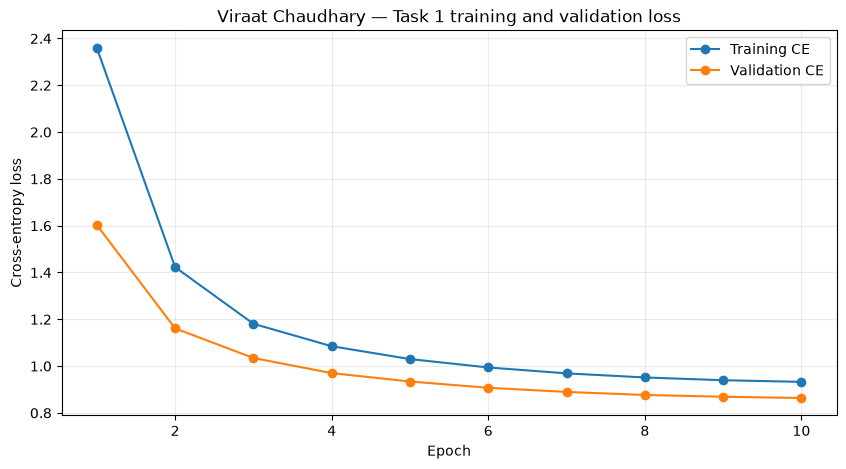

In [21]:
display(Markdown("## C7. Viraat loss curves — reconstructed from the committed epoch history"))

viraat_history = pd.read_csv(
    VIRAAT / "outputs/metrics/training_history.csv"
)

display(viraat_history)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(viraat_history["epoch"], viraat_history["training_loss"], marker="o", label="Training CE")
ax.plot(viraat_history["epoch"], viraat_history["validation_loss"], marker="o", label="Validation CE")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Viraat Chaudhary — Task 1 training and validation loss")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

In [22]:
display(Markdown("## C8. Viraat — complete reported metrics table"))

viraat_metrics_table = read_metrics_csv(VIRAAT)
display(viraat_metrics_table)

print(
    "This table is loaded directly from task1_llm/Viraat_Chaudhary/metrics_report.csv. "
    "The reported FP32 selected-checkpoint training/validation metrics are intentionally "
    "distinguished from the online epoch-average training loss."
)

## C8. Viraat — complete reported metrics table

,metric,value,checkpoint_epoch,evidence
0,training_cross_entropy_loss,8.575842e-01,10,outputs/metrics/evaluation_metrics.json
1,final_epoch_training_cross_entropy_loss,9.326997e-01,10,outputs/metrics/evaluation_metrics.json
2,validation_cross_entropy_loss,8.637022e-01,10,outputs/metrics/evaluation_metrics.json
3,perplexity,2.371926e+00,10,outputs/metrics/evaluation_metrics.json
4,bits_per_character,1.246059e+00,10,outputs/metrics/evaluation_metrics.json
5,generalization_gap,6.118000e-03,10,outputs/metrics/evaluation_metrics.json
6,top1_next_character_accuracy,7.278121e-01,10,outputs/metrics/evaluation_metrics.json
7,distinct_1,4.592593e-03,10,outputs/metrics/evaluation_metrics.json
8,distinct_2,4.215839e-02,10,outputs/metrics/evaluation_metrics.json
9,distinct_3,1.665923e-01,10,outputs/metrics/evaluation_metrics.json


This table is loaded directly from task1_llm/Viraat_Chaudhary/metrics_report.csv. The reported FP32 selected-checkpoint training/validation metrics are intentionally distinguished from the online epoch-average training loss.


In [23]:
display(Markdown("## C9. Viraat — exact reported failure cases"))

viraat_fail_md = (VIRAAT / "failure_analysis.md").read_text(encoding="utf-8")
display(Markdown(viraat_fail_md))

failure_json = VIRAAT / "analysis" / "failure_cases.json"
if failure_json.is_file():
    viraat_failures = load_json(failure_json)
    if isinstance(viraat_failures, dict):
        if isinstance(viraat_failures.get("cases"), list):
            display(pd.DataFrame(viraat_failures["cases"]))
        else:
            display(pd.DataFrame([viraat_failures]).T)
    elif isinstance(viraat_failures, list):
        display(pd.DataFrame(viraat_failures))

## C9. Viraat — exact reported failure cases

# Task 1 Failure Analysis - Viraat Chaudhary

Three manually reviewed failures from the saved model outputs.

## Case 1: Repetitive generation loop

Sample: `sample_001`; decoding: greedy; temperature: None.

> You are very sad. You are a good friend. You are very sad. You are a good friend. You are very sad. You are a good friend.

Observation: The same sentence pair appears three consecutive times in this excerpt, and the full continuation later repeats 'You are very sad.' many more times without developing the story. This greedy sample has a character-level repeated 4-gram rate of 0.748491. That is its individual rate; the reported aggregate rate of 0.174678 covers only the 27 sampled continuations and excludes greedy outputs.

Testable fix: As a decoding experiment, keep this checkpoint, the three prompts and the 500-character generation budget fixed. Compare greedy decoding with sampling at temperature 0.7 over several recorded seeds. Measure consecutive repeated-sentence runs and the character-level repeated 4-gram rate, and inspect grammar as well. Sampling may break the loop, but an improvement should be measured rather than assumed.

Evidence: outputs/samples/generated_samples.json

## Case 2: Unexplained speaker or character-name change

Sample: `sample_006`; decoding: sampled; temperature: 1.0.

> , there was a little girl called Jelie, "Zoomp! I love you. Thank you, Grandma!" Lily said.

Observation: The continuation introduces a girl called Jelie, but immediately attributes the quoted speech to Lily without introducing Lily or explaining the relationship. This leaves the speaker's identity ambiguous. The excerpt does not establish whether Lily is another character or an unintended replacement name. The example was sampled at temperature 1.0.

Testable fix: In a future training experiment, test whether additional training at a small learning rate improves character-name consistency while keeping the architecture and split fixed. Compare the resulting checkpoint with this frozen checkpoint on the same reserved prompts, generation length, temperature 1.0 and recorded sampling seeds. Count unexplained name changes and inspect validation loss. This is a proposed experiment, not a demonstrated fix.

Evidence: outputs/samples/generated_samples.json

## Case 3: Malformed words and grammar

Sample: `sample_018`; decoding: sampled; temperature: 1.3.

> Lily noticed down the tib legs. She splashed the stame. She's notice and kicked some chone flowersh.

Observation: The excerpt contains nonstandard word forms such as 'stame', 'chone' and 'flowersh', and 'She's notice' is grammatically malformed in this context. These errors make the events difficult to interpret even though the continuation contains familiar story words and a character name. This sample used temperature 1.3; one example cannot establish temperature as the only cause.

Testable fix: For a controlled decoding experiment, keep the checkpoint, prompts and 500-character generation budget fixed and compare temperatures 0.7, 1.0 and 1.3 over matched recorded seeds. Manually count malformed words and grammatical errors alongside repeated 4-gram rates. Test whether a lower temperature improves readability, and check whether that improvement comes with more repetition.

Evidence: outputs/samples/generated_samples.json


,sample_id,excerpt,failure_type,observation,testable_fix
0,sample_001,You are very sad. You are a good friend. You are very sad. You are a good friend. You are very sad. You are a good f...,Repetitive generation loop,"The same sentence pair appears three consecutive times in this excerpt, and the full continuation later repeats 'You...","As a decoding experiment, keep this checkpoint, the three prompts and the 500-character generation budget fixed. Com..."
1,sample_006,", there was a little girl called Jelie, ""Zoomp! I love you. Thank you, Grandma!"" Lily said.",Unexplained speaker or character-name change,"The continuation introduces a girl called Jelie, but immediately attributes the quoted speech to Lily without introd...","In a future training experiment, test whether additional training at a small learning rate improves character-name c..."
2,sample_018,Lily noticed down the tib legs. She splashed the stame. She's notice and kicked some chone flowersh.,Malformed words and grammar,"The excerpt contains nonstandard word forms such as 'stame', 'chone' and 'flowersh', and 'She's notice' is grammatic...","For a controlled decoding experiment, keep the checkpoint, prompts and 500-character generation budget fixed and com..."


# D. Final Task 1 comparison

This section separates three different questions:

1. **Architecture:** What structural design choices differ?
2. **Hyperparameters:** What training / regularization / scheduling choices differ?
3. **Metrics:** What did the frozen experiments actually measure?

The two models differ in several factors simultaneously, so the experiment does **not** establish that any single one of
pre-norm/post-norm, GELU/ReLU, tied/untied output weights, width, depth, dropout, batch size, or hardware alone caused the observed quality difference.

In [24]:
display(Markdown("## D1. Architecture comparison"))

architecture_comparison = pd.DataFrame([
    {
        "Property": "Tokenizer / unit",
        "Anshika": "Character-level",
        "Viraat": "Character-level",
    },
    {
        "Property": "Vocabulary size",
        "Anshika": infer_vocab_size(anshika_vocab),
        "Viraat": infer_vocab_size(viraat_vocab),
    },
    {
        "Property": "Context length",
        "Anshika": anshika_config["data"]["sequence_length"],
        "Viraat": viraat_config["data"]["sequence_length"],
    },
    {
        "Property": "Transformer blocks",
        "Anshika": anshika_config["model"]["num_layers"],
        "Viraat": viraat_config["model"]["num_layers"],
    },
    {
        "Property": "Normalization",
        "Anshika": anshika_config["model"]["normalization"],
        "Viraat": viraat_config["model"]["normalization"],
    },
    {
        "Property": "Model width",
        "Anshika": anshika_config["model"]["d_model"],
        "Viraat": viraat_config["model"]["d_model"],
    },
    {
        "Property": "Attention heads",
        "Anshika": anshika_config["model"]["num_heads"],
        "Viraat": viraat_config["model"]["num_heads"],
    },
    {
        "Property": "Head dimension",
        "Anshika": anshika_config["model"]["d_model"] // anshika_config["model"]["num_heads"],
        "Viraat": viraat_config["model"]["d_model"] // viraat_config["model"]["num_heads"],
    },
    {
        "Property": "Feed-forward width",
        "Anshika": anshika_config["model"]["d_ff"],
        "Viraat": viraat_config["model"]["d_ff"],
    },
    {
        "Property": "Activation",
        "Anshika": "GELU",
        "Viraat": viraat_config["model"].get("activation", "not named in YAML"),
    },
    {
        "Property": "Dropout",
        "Anshika": anshika_config["model"]["dropout"],
        "Viraat": viraat_config["model"]["dropout"],
    },
    {
        "Property": "Positional embeddings",
        "Anshika": anshika_config["model"]["positional_embeddings"],
        "Viraat": viraat_config["model"]["positional_embeddings"],
    },
    {
        "Property": "Input/output weight tying",
        "Anshika": anshika_config["model"]["tie_token_and_output_embeddings"],
        "Viraat": viraat_config["model"]["tie_token_and_output_embeddings"],
    },
    {
        "Property": "Trainable parameters",
        "Anshika": anshika_parameter_count,
        "Viraat": viraat_parameter_count,
    },
])

display(architecture_comparison)

## D1. Architecture comparison

,Property,Anshika,Viraat
0,Tokenizer / unit,Character-level,Character-level
1,Vocabulary size,101,96
2,Context length,256,256
3,Transformer blocks,5,4
4,Normalization,pre_layer_norm,post_layer_norm
5,Model width,240,256
6,Attention heads,6,8
7,Head dimension,40,32
8,Feed-forward width,960,1024
9,Activation,GELU,relu


In [25]:
display(Markdown("## D2. Hyperparameter comparison"))

def lookup(cfg, dotted, default=None):
    cur = cfg
    for part in dotted.split("."):
        if not isinstance(cur, dict) or part not in cur:
            return default
        cur = cur[part]
    return cur

comparison_keys = [
    ("Training sequences", "data.train_sequences"),
    ("Validation sequences", "data.validation_sequences"),
    ("Sequence length", "data.sequence_length"),
    ("Split seed", "data.split_seed"),
    ("Epochs", "training.epochs"),
    ("Batch size", "training.batch_size"),
    ("Peak learning rate", "training.learning_rate"),
    ("Minimum learning rate", "training.minimum_learning_rate"),
    ("Warmup ratio", "training.warmup_ratio"),
    ("Scheduler", "training.scheduler"),
    ("Weight decay", "training.weight_decay"),
    ("Adam beta1", "training.adam_beta1"),
    ("Adam beta2", "training.adam_beta2"),
    ("Gradient clip norm", "training.gradient_clip_norm"),
    ("Precision", "training.precision"),
    ("Mixed precision flag", "training.mixed_precision"),
    ("Training seed", "training.training_seed"),
    ("Max new characters", "generation.max_new_characters"),
    ("Temperatures", "generation.temperatures"),
    ("Samples / temperature", "generation.samples_per_temperature"),
]

hyperparameter_comparison = pd.DataFrame([
    {
        "Hyperparameter": label,
        "Anshika": lookup(anshika_config, key),
        "Viraat": lookup(viraat_config, key),
    }
    for label, key in comparison_keys
])

display(hyperparameter_comparison)

## D2. Hyperparameter comparison

,Hyperparameter,Anshika,Viraat
0,Training sequences,100000,100000
1,Validation sequences,10000,10000
2,Sequence length,256,256
3,Split seed,2661501,2661502
4,Epochs,10,10
5,Batch size,32,64
6,Peak learning rate,0.0003,0.0003
7,Minimum learning rate,0.00003,0.00003
8,Warmup ratio,0.05,0.1
9,Scheduler,cosine,cosine


In [26]:
display(Markdown("## D3. Complete metric comparison from the committed metric CSV files"))

def normalize_metric_frame(df, member):
    metric_col = next((c for c in df.columns if c.lower() == "metric"), df.columns[0])
    value_col = next(
        (c for c in df.columns if c.lower() in {"value", "metric_value", "result"}),
        df.columns[1],
    )
    out = df[[metric_col, value_col]].copy()
    out.columns = ["Metric", member]
    return out

a_metrics = normalize_metric_frame(anshika_metrics_table, "Anshika")
v_metrics = normalize_metric_frame(viraat_metrics_table, "Viraat")

metric_comparison = pd.merge(
    a_metrics,
    v_metrics,
    on="Metric",
    how="outer",
)

display(metric_comparison)

## D3. Complete metric comparison from the committed metric CSV files

,Metric,Anshika,Viraat
0,bits_per_character,1.000841e+00,1.246059e+00
1,distinct_1,4.370370e-03,4.592593e-03
2,distinct_2,3.970905e-02,4.215839e-02
3,distinct_3,1.581883e-01,1.665923e-01
4,final_epoch_training_cross_entropy_loss,NaN,9.326997e-01
5,generalization_gap,-3.553731e-02,6.118000e-03
6,generation_tokens_per_second,5.180794e+02,6.960131e+02
7,gradient_norm_max,1.163973e+01,3.309997e+00
8,gradient_norm_mean,7.671757e-01,6.247545e-01
9,loss_spike_count,0.000000e+00,0.000000e+00


# E. Live common-holdout evaluation — the strongest checkpoint verification

The members used different split seeds and their individual training/evaluation conventions are not perfectly interchangeable.

Therefore the repository contains `task1_llm/evaluate_common.py`, which was added specifically to make the final checkpoint comparison fair:

- same **10,000 windows** from the official validation holdout,
- same context length `256`,
- same evaluation batch size `32`,
- FP32 evaluation,
- each checkpoint uses its own frozen vocabulary/model source,
- no retraining,
- no checkpoint selection or tuning on this holdout.

This is the most important live evaluator cell in Task 1.

**Expected reported common-holdout results**

- Anshika: CE ≈ **0.69440728**, accuracy ≈ **78.1023%**
- Viraat: CE ≈ **0.86098925**, accuracy ≈ **72.9764%**

The code below invokes the repository's actual shared evaluator rather than reimplementing it in the notebook.

In [27]:
display(Markdown("## E1. Inspect the exact shared evaluator before executing it"))

common_evaluator = TASK1 / "evaluate_common.py"
if not common_evaluator.is_file():
    raise FileNotFoundError(common_evaluator)

source_lines = common_evaluator.read_text(encoding="utf-8").splitlines()

print("Evaluator:", common_evaluator.relative_to(ROOT))
print("SHA256:", sha256_file(common_evaluator))
print("Lines:", len(source_lines))

# Show the beginning and the lines that reference the frozen checkpoints/common cache/model source.
interesting = []
for i, line in enumerate(source_lines, start=1):
    low = line.lower()
    if (
        i <= 35
        or "best_model.pt" in line
        or "common_evaluation" in line
        or "model.py" in line
        or "batch" in low and "32" in line
        or "float32" in low
        or "fp32" in low
    ):
        interesting.append((i, line))

for i, line in interesting[:100]:
    print(f"{i:4d} | {line}")

## E1. Inspect the exact shared evaluator before executing it

Evaluator: task1_llm\evaluate_common.py
SHA256: 2ea63d33a211a32a4b57dcc79eee21e56ec881f545481e16ebd923980a97a935
Lines: 188
   1 | """Evaluate both trained decoders on the same official TinyStories validation text."""
   2 | 
   3 | from __future__ import annotations
   4 | 
   5 | import argparse
   6 | import csv
   7 | import hashlib
   8 | import importlib.util
   9 | import json
  10 | import os
  11 | import sys
  12 | from pathlib import Path
  13 | 
  14 | import torch
  15 | import yaml
  16 | 
  17 | 
  18 | def import_model(path, name):
  19 |     specification = importlib.util.spec_from_file_location(name, path)
  20 |     module = importlib.util.module_from_spec(specification)
  21 |     sys.modules[name] = module
  22 |     specification.loader.exec_module(module)
  23 |     return module
  24 | 
  25 | 
  26 | def verify_vocabulary_hash(checkpoint, vocabulary_path):
  27 |     """Match frozen bytes, allowing only an LF/CRLF checkout conversion."""
  28 |     if checkpoin

In [28]:
display(
    Markdown(
        "## E2. Run the common evaluator live"
    )
)

common_csv = (
    TASK1
    / "comparison"
    / "common_validation_comparison.csv"
)


# ============================================================
# SHORT WINDOWS CACHE PATH
#
# The repository path is long enough that Hugging Face's
# generated lock filenames can exceed the Windows path limit.
#
# Keep the dataset cache outside the long repository path.
# ============================================================

short_hf_cache = (
    Path.home()
    / "data266_task1_hf_cache"
)

short_hf_cache.mkdir(
    parents=True,
    exist_ok=True,
)


print(
    "Short Hugging Face cache:",
    short_hf_cache,
)


before_csv_sha = (
    sha256_file(
        common_csv
    )
    if common_csv.is_file()
    else None
)


before_csv_mtime = (
    common_csv.stat().st_mtime_ns
    if common_csv.is_file()
    else None
)


env = os.environ.copy()

env[
    "PYTHONDONTWRITEBYTECODE"
] = "1"

env[
    "TASK1_HF_CACHE"
] = str(
    short_hf_cache
)

env[
    "HF_HOME"
] = str(
    short_hf_cache
    / "hf_home"
)

env[
    "HF_DATASETS_CACHE"
] = str(
    short_hf_cache
    / "datasets"
)

env[
    "HF_HUB_DISABLE_SYMLINKS_WARNING"
] = "1"


# ============================================================
# RUN THE REPOSITORY'S ACTUAL COMMON EVALUATOR
# AND STREAM ITS OUTPUT LIVE
# ============================================================

print()
print(
    "=" * 80
)

print(
    "STARTING LIVE COMMON-HOLDOUT EVALUATION"
)

print(
    "=" * 80
)

print()


common_eval_started = (
    time.perf_counter()
)


process = subprocess.Popen(
    [
        sys.executable,
        str(
            common_evaluator
        ),
    ],

    cwd=str(
        ROOT
    ),

    env=env,

    stdout=subprocess.PIPE,

    stderr=subprocess.STDOUT,

    text=True,

    bufsize=1,
)


if process.stdout is None:

    raise RuntimeError(
        "Unable to capture evaluator output."
    )


for line in process.stdout:

    print(
        line,
        end="",
    )


return_code = (
    process.wait()
)


common_eval_elapsed = (
    time.perf_counter()
    -
    common_eval_started
)


print()
print(
    "Common evaluator return code:",
    return_code,
)

print(
    "Common evaluator runtime:",
    f"{common_eval_elapsed:.2f} seconds",
)


if return_code != 0:

    raise RuntimeError(
        "Common evaluator failed. "
        "See the live evaluator output above."
    )


if not common_csv.is_file():

    raise FileNotFoundError(
        "Evaluator succeeded but "
        "common_validation_comparison.csv "
        "was not produced."
    )


common_eval_succeeded = True


print()
print(
    "=" * 80
)

print(
    "COMMON EVALUATOR EXECUTION: PASSED"
)

print(
    "=" * 80
)

## E2. Run the common evaluator live

Short Hugging Face cache: C:\Users\aradh\data266_task1_hf_cache

STARTING LIVE COMMON-HOLDOUT EVALUATION

{"event": "RUN_START", "stage": "common_evaluation", "created_utc": "2026-10-08T00:16:31.468107+00:00"}
{"event": "FROZEN_VOCABULARY_VERIFIED", "member": "Anshika_Goel", "checkpoint_vocabulary_sha256": "8ac5c75e1ebdc21f991c368d2ac71c279ce5c747956fc9cd29a09aa9e74c22b1", "vocabulary_file_sha256": "8ac5c75e1ebdc21f991c368d2ac71c279ce5c747956fc9cd29a09aa9e74c22b1", "hash_match_representation": "exact_bytes"}
{"event": "FROZEN_VOCABULARY_VERIFIED", "member": "Viraat_Chaudhary", "checkpoint_vocabulary_sha256": "f470ced134d2fcc6ac7582cfbde25ac75a851f5fd2e682676dbc720d6bb30964", "vocabulary_file_sha256": "f470ced134d2fcc6ac7582cfbde25ac75a851f5fd2e682676dbc720d6bb30964", "hash_match_representation": "exact_bytes"}

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]
README.md: 100%|##########| 1.06k/1.06k [00:00<?, ?B/s]


data/train-00000-of-00004-2d5a1467fff108(…): reconstructing file

In [32]:
display(
    Markdown(
        "## E3. Show the freshly evaluated common-holdout metrics"
    )
)


if not globals().get(
    "common_eval_succeeded",
    False,
):

    raise RuntimeError(
        "The common evaluator has not completed "
        "successfully in this kernel. "
        "Run E2 successfully before E3."
    )


if not common_csv.is_file():

    raise FileNotFoundError(
        "common_validation_comparison.csv "
        "was not produced."
    )


common_results = (
    pd.read_csv(
        common_csv
    )
)


display(
    common_results
)


after_csv_sha = (
    sha256_file(
        common_csv
    )
)


after_csv_mtime = (
    common_csv
    .stat()
    .st_mtime_ns
)


print()
print(
    "CSV SHA before evaluation:",
    before_csv_sha,
)

print(
    "CSV SHA after evaluation :",
    after_csv_sha,
)


if (
    before_csv_sha
    is not None
):

    print(
        "CSV byte-for-byte identical to pre-run artifact:",
        before_csv_sha
        == after_csv_sha,
    )


if (
    before_csv_mtime
    is not None
):

    print(
        "CSV was refreshed during this run:",
        after_csv_mtime
        > before_csv_mtime,
    )


print()
print(
    "These rows are from the successfully "
    "completed live common-holdout evaluator."
)

## E3. Show the freshly evaluated common-holdout metrics

,member,common_validation_ce,common_next_character_accuracy,unknown_character_count,checkpoint_epoch,checkpoint_sha256,checkpoint_vocabulary_sha256,vocabulary_file_sha256,hash_match_representation
0,Anshika_Goel,0.694407,0.781024,5,10,64ad99efc0bf2e49959d3ef54bf5373a4c3a974f0fa333ae4a37e62fac9d2ba3,8ac5c75e1ebdc21f991c368d2ac71c279ce5c747956fc9cd29a09aa9e74c22b1,8ac5c75e1ebdc21f991c368d2ac71c279ce5c747956fc9cd29a09aa9e74c22b1,exact_bytes
1,Viraat_Chaudhary,0.860989,0.729764,8,10,52e2bddd0dadea877d0230f95e5e267cdd87c2f9c4401ff5817a5bc92d0093f1,f470ced134d2fcc6ac7582cfbde25ac75a851f5fd2e682676dbc720d6bb30964,f470ced134d2fcc6ac7582cfbde25ac75a851f5fd2e682676dbc720d6bb30964,exact_bytes



CSV SHA before evaluation: bdfeaa225d845d9280e3ecace8e351e785b5ba90c60442a2b4e68fc9d9e07fa3
CSV SHA after evaluation : b5497d9d72db40fb444d90a327d7abe6293fd1c447de53c2c3978b3f0b9c9549
CSV byte-for-byte identical to pre-run artifact: False
CSV was refreshed during this run: True

These rows are from the successfully completed live common-holdout evaluator.


In [33]:
display(
    Markdown(
        "## E4. Verify live common-holdout results against the final reported values"
    )
)


if not globals().get(
    "common_eval_succeeded",
    False,
):

    raise RuntimeError(
        "Run E2 successfully before verifying metrics."
    )


required_columns = {
    "member",
    "common_validation_ce",
    "common_next_character_accuracy",
}


missing_columns = (
    required_columns
    -
    set(
        common_results.columns
    )
)


if missing_columns:

    raise RuntimeError(
        "Common comparison CSV is missing "
        f"required columns: {missing_columns}"
    )


EXPECTED_COMMON = {

    "Anshika_Goel": {

        "ce":
            0.69440728,

        "accuracy":
            0.781023,
    },

    "Viraat_Chaudhary": {

        "ce":
            0.86098925,

        "accuracy":
            0.729764,
    },
}


verification_rows = []


for (
    member,
    expected,
) in EXPECTED_COMMON.items():

    member_rows = (
        common_results[
            common_results[
                "member"
            ]
            == member
        ]
    )


    if len(
        member_rows
    ) != 1:

        raise RuntimeError(
            f"Expected exactly one row for {member}."
        )


    row = (
        member_rows.iloc[
            0
        ]
    )


    live_ce = float(
        row[
            "common_validation_ce"
        ]
    )


    live_accuracy = float(
        row[
            "common_next_character_accuracy"
        ]
    )


    verification_rows.append(
        {
            "Member":
                member,

            "Live common CE":
                live_ce,

            "Reported common CE":
                expected[
                    "ce"
                ],

            "|CE difference|":
                abs(
                    live_ce
                    -
                    expected[
                        "ce"
                    ]
                ),

            "Live common accuracy":
                live_accuracy,

            "Reported common accuracy":
                expected[
                    "accuracy"
                ],

            "|Accuracy difference|":
                abs(
                    live_accuracy
                    -
                    expected[
                        "accuracy"
                    ]
                ),
        }
    )


common_verification = (
    pd.DataFrame(
        verification_rows
    )
)


display(
    common_verification
)


ce_ok = (
    common_verification[
        "|CE difference|"
    ]
    < 5e-4
).all()


accuracy_ok = (
    common_verification[
        "|Accuracy difference|"
    ]
    < 5e-4
).all()


print()
print(
    "CE reproduction passed:",
    ce_ok,
)

print(
    "Accuracy reproduction passed:",
    accuracy_ok,
)


if not (
    ce_ok
    and accuracy_ok
):

    raise RuntimeError(
        "Live common-holdout metrics "
        "do not match reported values."
    )


print()
print(
    "=" * 80
)

print(
    "LIVE COMMON-HOLDOUT METRICS "
    "MATCH THE REPORTED VALUES: PASSED"
)

print(
    "=" * 80
)

## E4. Verify live common-holdout results against the final reported values

,Member,Live common CE,Reported common CE,|CE difference|,Live common accuracy,Reported common accuracy,|Accuracy difference|
0,Anshika_Goel,0.694407,0.694407,4.227905e-09,0.781024,0.781023,8.281250e-07
1,Viraat_Chaudhary,0.860989,0.860989,2.868652e-09,0.729764,0.729764,6.250000e-08



CE reproduction passed: True
Accuracy reproduction passed: True

LIVE COMMON-HOLDOUT METRICS MATCH THE REPORTED VALUES: PASSED


# F. Final evaluator-facing Task 1 checklist

At the end of the live demonstration you should be able to point to the outputs above and say:

### Checkpoints
- Both members' checkpoint directories were enumerated.
- `best_model.pt` and `last_checkpoint.pt` were opened.
- Saved state tensors were checked for finite values.
- The selected best checkpoints were reconstructed using each member's committed source.

### Data
- The experiment uses the pinned TinyStories revision recorded in each YAML configuration.
- Training and validation use 100,000 / 10,000 fixed-length sequences with 256-character context.
- The notebook shows a real processed validation input when the local processed representation is available.

### Model execution
- Both best checkpoints produced a fresh live continuation.
- The live outputs are generated by the loaded checkpoint, not copied from the report.

### Metrics
- The complete reported metric CSV is shown for each member.
- Anshika's own validation checkpoint metrics are recomputed live from the full local validation tensor.
- Viraat's frozen checkpoint is evaluated live on the same TinyStories validation text available locally, after decoding the text and re-encoding it with Viraat's own frozen character vocabulary. This is a same-text demonstration, not a claim that Viraat's original member-specific split is locally available.
- Most importantly, **both checkpoints are re-evaluated live by the shared common-holdout evaluator**.

### Loss curves
- Training and validation curves are reconstructed from the committed epoch-level history rather than shown only as a static screenshot.

### Failure cases
- The notebook displays each member's committed `failure_analysis.md`.
- These are the exact saved outputs analyzed in the report, so the failure demonstration remains traceable to the original experiment.

### Fair model comparison
- Anshika's model is the preferred Task 1 checkpoint under the common quality criteria because it has lower common validation CE and higher common next-character accuracy.
- Viraat's run is substantially faster, but the training throughput comparison is confounded by different GPUs, batch sizes, precision paths, and architecture choices.
- Because multiple architectural and training factors differ together, the experiment does not prove that a single design choice caused the performance gap.

In [34]:
display(
    Markdown(
        "## Final Task 1 demo integrity verification"
    )
)


final_checks = pd.DataFrame(
    [
        {
            "Check":
                "Anshika best checkpoint loaded",

            "Passed":
                isinstance(
                    anshika_model,
                    torch.nn.Module,
                ),
        },

        {
            "Check":
                "Anshika parameter count",

            "Passed":
                anshika_parameter_count
                == 3_557_861,
        },

        {
            "Check":
                "Anshika live validation completed",

            "Passed":
                "anshika_live_metrics"
                in globals(),
        },

        {
            "Check":
                "Viraat best checkpoint loaded",

            "Passed":
                isinstance(
                    viraat_model,
                    torch.nn.Module,
                ),
        },

        {
            "Check":
                "Viraat parameter count",

            "Passed":
                viraat_parameter_count
                == 3_273_824,
        },

        {
            "Check":
                "Viraat shared-text evaluation completed",

            "Passed":
                "viraat_same_text_metrics"
                in globals(),
        },

        {
            "Check":
                "Common evaluator completed successfully",

            "Passed":
                globals().get(
                    "common_eval_succeeded",
                    False,
                ),
        },

        {
            "Check":
                "Common metric verification passed",

            "Passed":
                (
                    "ce_ok"
                    in globals()
                    and bool(
                        ce_ok
                    )
                    and bool(
                        accuracy_ok
                    )
                ),
        },
    ]
)


display(
    final_checks
)


all_checks_passed = bool(
    final_checks[
        "Passed"
    ]
    .all()
)


print()
print(
    "All final checks passed:",
    all_checks_passed,
)


if not all_checks_passed:

    raise RuntimeError(
        "Task 1 demo notebook "
        "has an incomplete verification."
    )


print()
print(
    "=" * 88
)

print(
    "TASK 1 LIVE DEMO NOTEBOOK: "
    "ALL FINAL INTEGRITY CHECKS PASSED"
)

print(
    "=" * 88
)

## Final Task 1 demo integrity verification

,Check,Passed
0,Anshika best checkpoint loaded,True
1,Anshika parameter count,True
2,Anshika live validation completed,True
3,Viraat best checkpoint loaded,True
4,Viraat parameter count,True
5,Viraat shared-text evaluation completed,True
6,Common evaluator completed successfully,True
7,Common metric verification passed,True



All final checks passed: True

TASK 1 LIVE DEMO NOTEBOOK: ALL FINAL INTEGRITY CHECKS PASSED
